In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Basic Graph

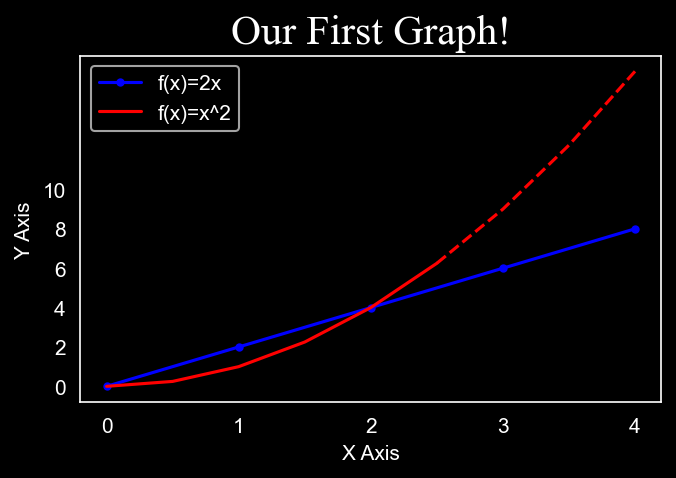

In [3]:
x = [0, 1, 2, 3, 4]
y = [0, 2, 4, 6, 8]

#  Resize your Graph
plt.figure(figsize=(5, 3), dpi=150)

#  Line Number One
# plt.plot(x, y, label='f(x)=2x', color='blue', linewidth=2, linestyle='--', marker='.', markersize=10, markeredgecolor='red')
plt.plot(x, y, 'b.-', label='f(x)=2x')

#  Line Number Two
x2 = np.arange(0, 4.5, 0.5)
plt.plot(x2[:6], x2[:6]**2, 'r-', label='f(x)=x^2')
plt.plot(x2[5:], x2[5:]**2, 'r--')

plt.title('Our First Graph!', fontdict={'fontname': 'Times New Roman', 'fontsize': 20})
plt.grid(False)
plt.xlabel('X Axis')
plt.ylabel('Y Axis')

plt.legend()

plt.xticks([0, 1, 2, 3, 4])
plt.yticks([0, 2, 4, 6, 8, 10])

plt.savefig('resources/my_graph.png', dpi=300)

plt.show()

### Bar Chart (Столбчатая диаграмма)

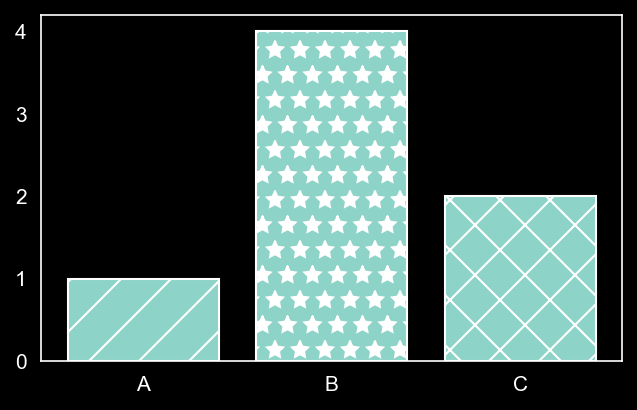

In [4]:
labels = ['A', 'B', 'C']
values = [1, 4, 2]

plt.figure(figsize=(5, 3), dpi=150)
plt.grid(False)

bars = plt.bar(labels, values)

bars[0].set_hatch('/')
bars[1].set_hatch('*')
bars[2].set_hatch('x')

plt.show()

# Real World Examples

## Line Graph

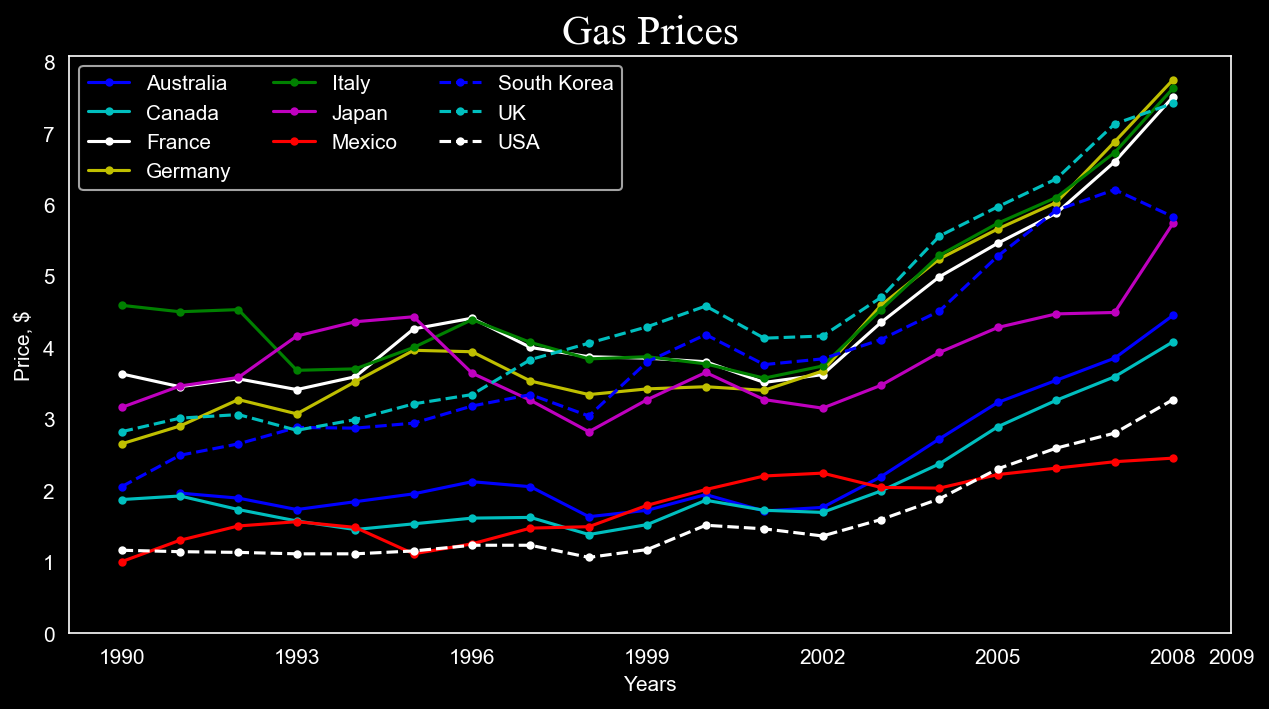

In [5]:
gas = pd.read_csv('resources/gas_prices.csv')

plt.figure(figsize=(10, 5), dpi=150)
plt.grid(False)
plt.title('Gas Prices', fontdict={'fontname': 'Times New Roman', 'fontsize': 20})

colors, lines = ['b', 'c', 'w', 'y', 'g', 'm', 'r'], ['-', '--', '-.', ':']
i_color, i_line = 0, 0
for country in gas.columns:
    if country != 'Year':
        plt.plot(gas['Year'], gas[country], colors[i_color] + '.' + lines[i_line], label=country)
        i_color += 1
        if i_color == len(colors):
            i_color = 0
            i_line += 1

plt.xlabel('Years')
plt.ylabel('Price, $')

plt.xticks(gas['Year'][::3].to_list() + [2009])
plt.yticks(np.arange(0, 9, 1))

plt.legend(ncol=3)

plt.savefig('resources/gas_prices_graph.png', dpi=300)
plt.show()

## Histogram

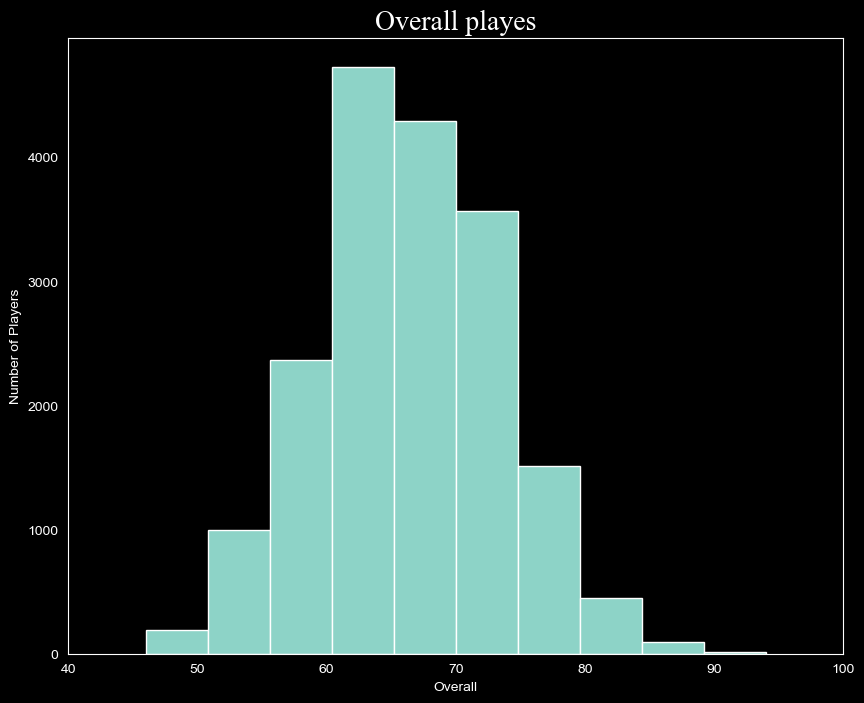

In [6]:
players = pd.read_csv('resources/fifa_data.csv', index_col=0)

plt.figure(figsize=(10, 8))
plt.grid(False)
plt.title('Overall playes', fontdict={'fontname': 'Times New Roman', 'fontsize': 20})

plt.hist(players['Overall'], bins=10)

plt.xticks([40, 50, 60, 70, 80, 90, 100])

plt.xlabel('Overall')
plt.ylabel('Number of Players')

plt.show()

## Pie Charts

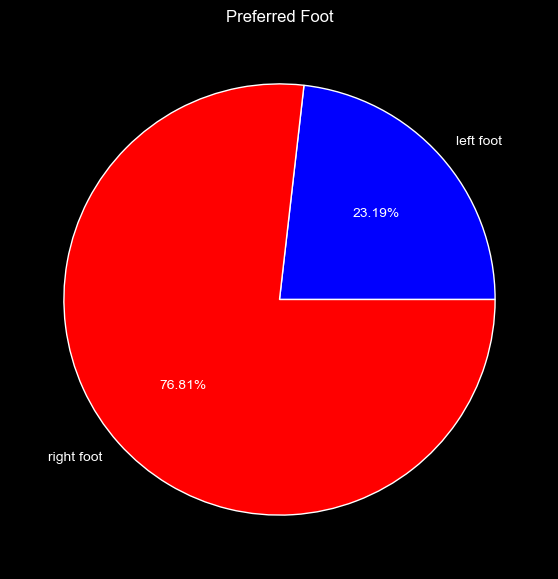

In [7]:
# left = players[players['Preferred Foot'] == 'Left']
left, right = players['Preferred Foot'].value_counts().sort_index().to_list()

plt.figure(figsize=(7, 7))
plt.title('Preferred Foot')

plt.pie([left, right], labels=['left foot', 'right foot'], colors=['b', 'r'], autopct='%.2f%%')

plt.savefig('resources/preferred_foot.png', dpi=300)
plt.show()

In [ ]:
players['Weight'] = [int(x.strip('lbs')) if type(x)==str else x for x in players['Weight']]

light = players[players['Weight'] < 125].count()['Weight']
light_medium = players[(players['Weight'] >= 125) & (players['Weight'] < 150)].count()['Weight']
medium = players[(players['Weight'] >= 150) & (players['Weight'] < 175)].count()['Weight']
medium_heavy = players[(players['Weight'] >= 175) & (players['Weight'] < 200)].count()['Weight']
heavy = players[players['Weight'] >= 200].count()['Weight']

weights = [light, light_medium, medium, medium_heavy, heavy]
labels = ['<125', '125-150', '150-175', '175-200', '>200']
explodes = [0.5, 0.2, 0, 0.2, 0.4]

plt.title('Weight Distribution of FIFA Players (in bls)')
plt.pie(weights, colors=['c', 'b', 'r', 'y', 'g'], autopct='%.2f%%', labels=labels, explode=explodes)
plt.show()

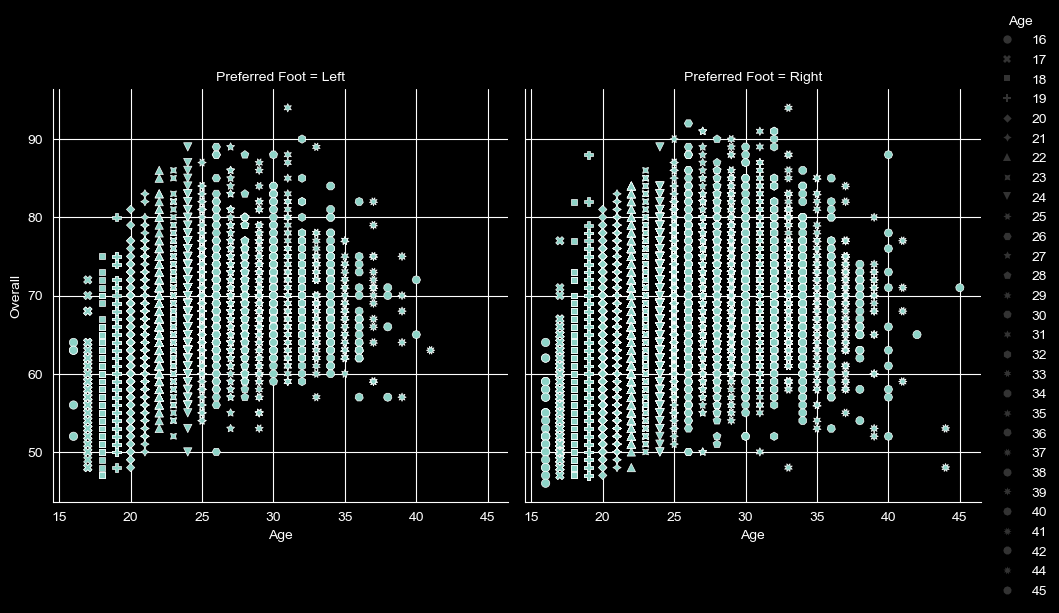

In [31]:
# gas
# players

sns.relplot(data=players, x='Age', y='Overall', style='Age', col='Preferred Foot')
plt.show()

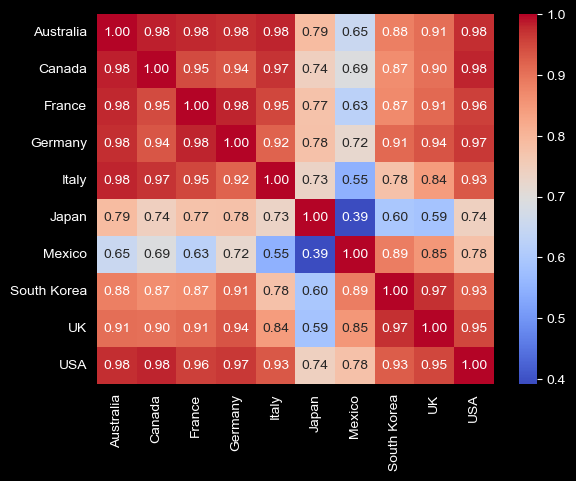

In [60]:
# gas.iloc[:, 1:].corr()

# sns.heatmap(data=gas.iloc[:, 1:], annot=True, cmap='coolwarm', fmt='.2f')
sns.heatmap(data=gas.iloc[:, 1:].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0)
plt.show()

In [ ]:
sns.pairplot(gas)
plt.show()

In [ ]:
# gas

sns.violinplot(x=gas['Year'], y=gas['Germany'], data=gas)
plt.show()

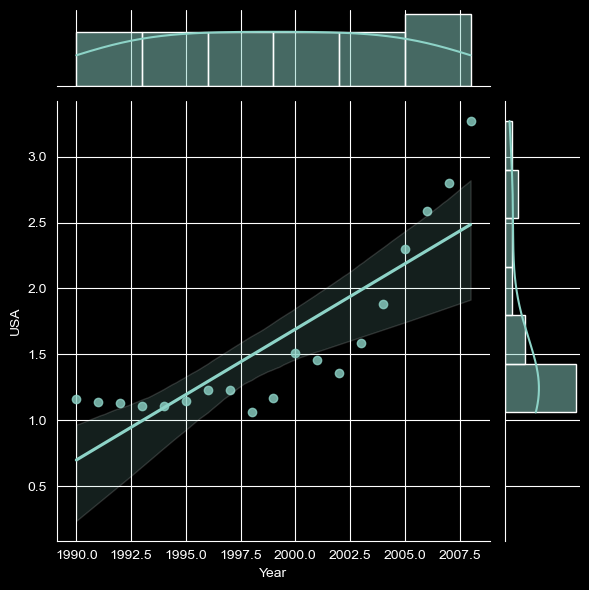

In [67]:
# gas

sns.jointplot(x=gas['Year'], y=gas['USA'], data=gas, kind='reg')
plt.show()